In [83]:
import pandas as pd
from scipy.stats import pearsonr
from scipy.stats import zscore
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

### Figure 4D

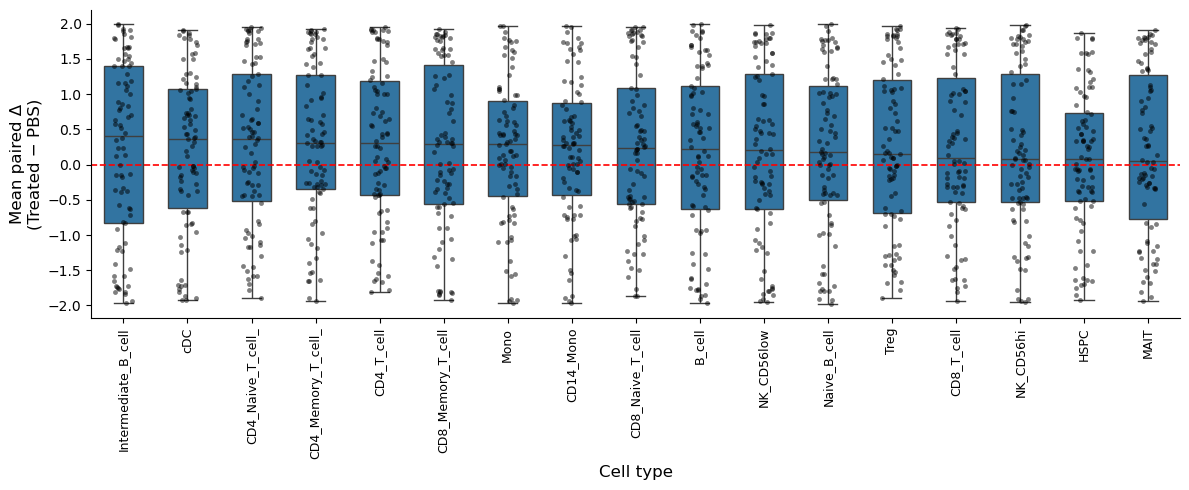

In [84]:
# DATA
pbmc_paired_delta=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/pbmc_paired_delta.csv",index_col='Unnamed: 0')
# ============================================================

df_plot = pbmc_paired_delta.copy()
# Remove missing values
df_plot = df_plot.dropna(
    subset=["mean_paired_delta"]
)


# ============================================================
# ORDER CELL TYPES BY MEDIAN PAIRED DELTA
# ============================================================

cell_order = (
    df_plot
    .groupby("cell_type")["mean_paired_delta"]
    .median()
    .sort_values(ascending=False)
    .index
)


# ============================================================
# BOXPLOT
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=df_plot,
    x="cell_type",
    y="mean_paired_delta",
    order=cell_order,
    showfliers=False,
    width=0.6,
    ax=ax
)

# Individual cytokines
sns.stripplot(
    data=df_plot,
    x="cell_type",
    y="mean_paired_delta",
    order=cell_order,
    color="black",
    size=3.5,
    alpha=0.5,
    jitter=0.15,
    ax=ax
)

# Zero reference
ax.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=1.2
)

ax.set_xlabel("Cell type", fontsize=12)

ax.set_ylabel(
    "Mean paired Δ\n(Treated − PBS)",
    fontsize=12
)

ax.tick_params(
    axis="x",
    rotation=90,
    labelsize=9
)

sns.despine()

plt.tight_layout()
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/cytokine_delta_across_pbmc_cell_type.svg",
#    format="svg",
#    bbox_inches="tight"
#)
plt.show()

In [85]:
df_delta_stats=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/df_delta_pbmc.csv",index_col='Unnamed: 0')
df=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/FCNN_xgboost_ridge.csv",index_col='Unnamed: 0')
filt_tcga_cyt_list=list(df[df['FCNN_CV']>0.6].index)

### getting only those cytokine-cell type delta for which CV>0.6

df_delta_stats=df_delta_stats[df_delta_stats['cytokine'].isin(filt_tcga_cyt_list)]

In [86]:
df_sig_positive = df_delta_stats[
    (df_delta_stats["mean_paired_delta"] > 0) &
    (df_delta_stats["pvalue"] < 0.05)
].copy()

In [87]:
df_delta_matrix = df_sig_positive.pivot_table(
    index="cell_type",
    columns="cytokine",
    values="mean_paired_delta"
)
df = df_delta_matrix.reindex(cell_order)

In [88]:
# Count number of cell types in which each cytokine appears
cytokine_counts = df.notna().sum(axis=0)

# Order cytokines from most frequent to least frequent
cytokine_order = (
    cytokine_counts
    .sort_values(ascending=False)
    .index
)

# Reorder columns
df1 = df[cytokine_order]

### Figure 4E

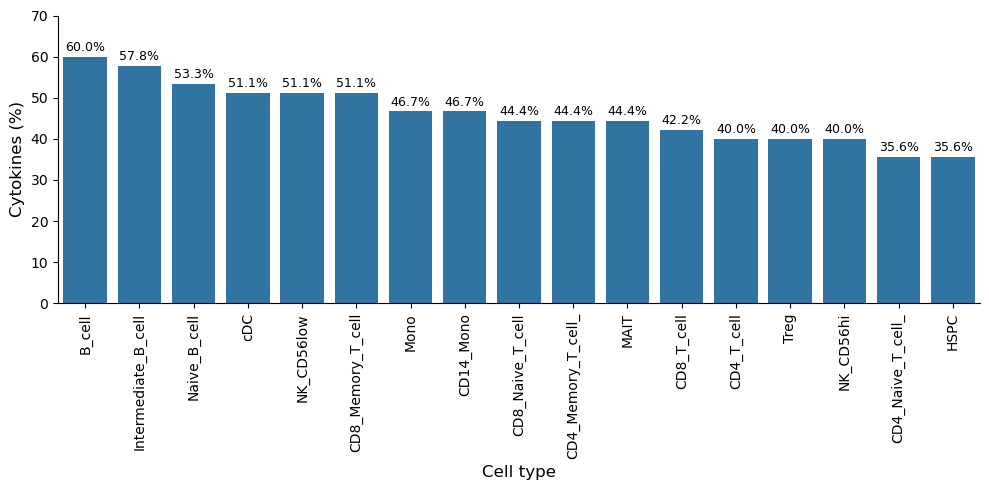

In [89]:
# ============================================================
# 1. DATA  number of cytokine significinatly elevated in cell types of treated samples
# ============================================================

data = {
    "Intermediate_B_cell": 26,
    "cDC": 23,
    "CD4_Naive_T_cell_": 16,
    "CD4_Memory_T_cell_": 20,
    "CD4_T_cell": 18,
    "CD8_Memory_T_cell": 23,
    "Mono": 21,
    "CD14_Mono": 21,
    "CD8_Naive_T_cell": 20,
    "B_cell": 27,
    "NK_CD56low": 23,
    "Naive_B_cell": 24,
    "Treg": 18,
    "CD8_T_cell": 19,
    "NK_CD56hi": 18,
    "HSPC": 16,
    "MAIT": 20
}

df_count = pd.DataFrame(
    list(data.items()),
    columns=["cell_type", "count"]
)

# ============================================================
# 2. CALCULATE PERCENTAGE
# ============================================================

df_count["percentage"] = (df_count["count"] / 45) * 100

# Sort highest to lowest
df_count = (
    df_count
    .sort_values("percentage", ascending=False)
    .reset_index(drop=True)
)

# ============================================================
# 3. BAR PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=df_count,
    x="cell_type",
    y="percentage",
    order=df_count["cell_type"],
    ax=ax
)

ax.set_xlabel("Cell type", fontsize=12)
ax.set_ylabel("Cytokines (%)", fontsize=12)

ax.tick_params(
    axis="x",
    rotation=90,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

# Add percentage above each bar
for container in ax.containers:
    labels = [
        f"{v:.1f}%"
        for v in df_count["percentage"]
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=9,
        padding=2
    )

# Optional: percentage scale
ax.set_ylim(0, 70)

# Clean manuscript style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/cell_type_cytokine_percentage.svg",
#    format="svg",
#    bbox_inches="tight"
#)

#plt.savefig(
#    "cell_type_cytokine_percentage.pdf",
#    format="pdf",
#    bbox_inches="tight"
#)

plt.show()

### Supplementary Figure 3

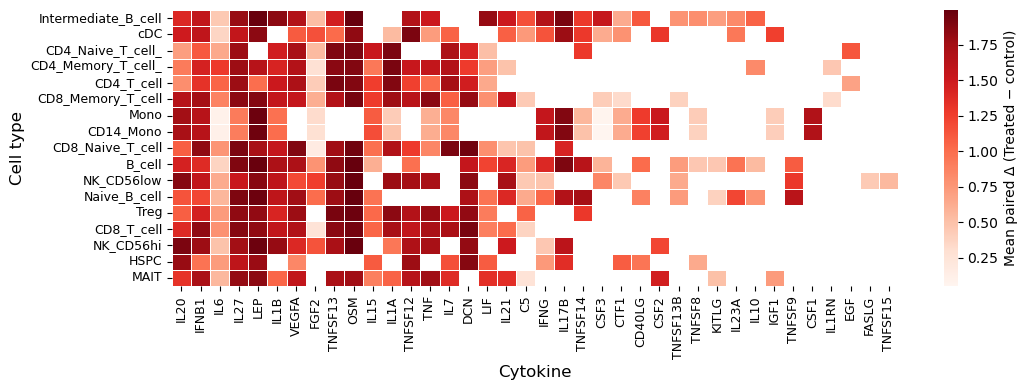

In [90]:
# Figure
plt.figure(figsize=(11, 4))

sns.heatmap(
    df1,
    cmap="Reds",
    vmin=0.05,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "Mean paired Δ (Treated − control)"
    }
)

plt.xlabel("Cytokine", fontsize=12)
plt.ylabel("Cell type", fontsize=12)

plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

# Save as vector SVG for manuscript
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/TxCyto_mean_paired_delta_heatmap.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()

### Figure 4F

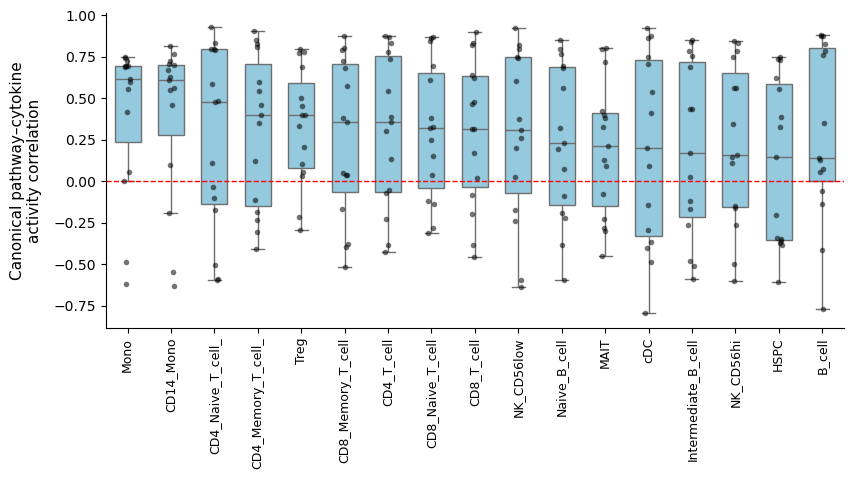

In [91]:
# TxCyto vs canonical pathway correlation values
df_treated_cyt_pathway_corr=pd.read_csv("/data/kumarr17/figures_to_upload/supplementray_table/imp_cytokine_pathways_correlation_sc.csv",index_col='Unnamed: 0')
# ============================================================
df_plot = (df_treated_cyt_pathway_corr.dropna(subset=["TxCyto_Pathway_Correlation"]).copy())
# ============================================================
# ORDER CELL TYPES BY MEDIAN
# ============================================================
cell_type_order = (df_plot.groupby("Cell_type")["TxCyto_Pathway_Correlation"].median().sort_values(ascending=False).index.tolist())

## Figure
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=df_plot,x="Cell_type",y="TxCyto_Pathway_Correlation",order=cell_type_order,color="skyblue",width=0.60,showfliers=False,linewidth=1,ax=ax)

sns.stripplot(data=df_plot,x="Cell_type",y="TxCyto_Pathway_Correlation",order=cell_type_order,color="black",size=4,alpha=0.55,jitter=0.08,ax=ax)

# ============================================================
# ZERO LINE
# ============================================================
ax.axhline(y=0,linestyle="--",color="red",linewidth=1)
# ============================================================
# AXIS LABELS
# ============================================================

ax.set_xlabel("")
ax.set_ylabel("Canonical pathway–cytokine\n"
    "activity correlation",fontsize=11,labelpad=8)
ax.tick_params(axis="x",labelrotation=90,labelsize=9)
ax.tick_params(axis="y",labelsize=10)


# ============================================================
# CLEAN Figure style
# ============================================================

sns.despine(ax=ax)
ax.grid(False)


fig.subplots_adjust(
    left=0.16,
    right=0.98,
    bottom=0.27,
    top=0.97
)
# Save as vector SVG for manuscript
#fig.savefig(
#    "/data/kumarr17/figures_to_upload/Figure3/TxCyto_cytokine_pathway_corr_boxplot.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()